# Experiments 9-12: Hizb Groupings + Random Sampling

Four new experiments, all using the same 35 well-documented poets from
Experiment 7/8:

- **Experiment 9:** the Quran's 60 traditional "hizb" (parts) as 60
  separate authors, clustered with the 35 poets (95 total).
- **Experiment 10:** every 2 consecutive hizb merged into one unit (30
  groups), clustered with the 35 poets (65 total).
- **Experiment 11:** ONE randomly chosen surah, clustered with the 35
  poets. Repeated 10 times with 10 different random surahs.
- **Experiment 12:** a random SET of 10 surahs merged into one entity,
  clustered with the 35 poets. Repeated 10 times with 10 different
  random sets.

**Note on this notebook's slow step:** Experiments 9-12 need
ayah-by-ayah embeddings (not just per-surah averages, since hizb
boundaries cut across surah boundaries), so this notebook embeds all
6,236 ayat individually the first time it runs. That's cached
afterward, same as everything else.

**Before you start:** put `poems.db` in the same folder as this
notebook.

Run cells top to bottom, **Shift+Enter**. First run: ~15-25 min
(the ayah-level embedding step). Later runs: much faster.

In [1]:
# CELL 1 -- Install packages
!pip -q install sentence-transformers torch scikit-learn umap-learn hdbscan pandas numpy matplotlib seaborn scipy requests


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2 -- Configuration
import re, sqlite3, hashlib, json, warnings, pickle
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

warnings.filterwarnings("ignore")

DB_PATH = Path("poems.db")
CACHE_DIR = Path("quran_cache"); CACHE_DIR.mkdir(exist_ok=True)
EMBED_CACHE_DIR = Path("embed_cache"); EMBED_CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("output/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("output/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("output/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SBERT_MODEL_NAME = "akhooli/Arabic-SBERT-100K"
MAX_VERSES_PER_POEM = 20

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS_HIGH = 50
UMAP_METRIC = "cosine"
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES = 3

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found -- will run on CPU (slower).")

def split_verses(poem_text):
    if not poem_text or not isinstance(poem_text, str):
        return []
    verses = re.split(r'[\n\r]+|[.!\u061F?\u061B;]+', poem_text)
    return [v.strip() for v in verses if len(v.strip()) > 10]

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 11})
print("Config loaded.")

GPU available: NVIDIA GeForce RTX 4080 SUPER
Config loaded.


In [3]:
# CELL 3 -- Load the 260 poets from poems.db
conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query(
    "SELECT poet_name, poem_title, poem_text, poem_type, poem_meter, verses_count "
    "FROM poems WHERE poet_name IS NOT NULL AND poem_text IS NOT NULL "
    "AND LENGTH(poem_text) >= 50",
    conn,
)
conn.close()

df["poem_hash"] = df["poem_text"].apply(lambda t: hashlib.md5(t.strip().encode("utf-8")).hexdigest())
df = df.drop_duplicates(subset=["poem_hash"]).copy()

poems_by_poet = defaultdict(list)
for _, row in df.iterrows():
    poems_by_poet[row["poet_name"]].append(row["poem_text"])
poems_by_poet = dict(poems_by_poet)

poet_total_verses = {
    poet: sum(len(split_verses(p)) for p in poems)
    for poet, poems in poems_by_poet.items()
}

print(f"Poets loaded: {len(poems_by_poet)}")

Poets loaded: 260


In [4]:
# CELL 4 -- Fetch Quran text WITH hizb-quarter metadata (needed for Exp 9/10)
cache_file = CACHE_DIR / "quran_ayat_with_hizb.json"

if cache_file.exists():
    print("Loading Quran (with hizb metadata) from local cache...")
    with open(cache_file, encoding="utf-8") as f:
        surahs_raw = json.load(f)
else:
    print("Fetching Quran from Al Quran Cloud API (includes hizb-quarter field)...")
    resp = requests.get("https://api.alquran.cloud/v1/quran/quran-uthmani", timeout=60)
    resp.raise_for_status()
    surahs_raw = resp.json()["data"]["surahs"]
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(surahs_raw, f, ensure_ascii=False)
    print("Fetched and cached.")

# Sanity check: confirm hizbQuarter field is actually present
sample_ayah = surahs_raw[0]["ayahs"][0]
assert "hizbQuarter" in sample_ayah, "hizbQuarter field missing from API response!"
print(f"hizbQuarter field confirmed present (sample value: {sample_ayah['hizbQuarter']})")

surah_names = {}
surah_poem_text = {}
ayah_records = []   # flat list: one row per ayah, with surah/ayah/hizb info
for s in surahs_raw:
    snum = s["number"]
    surah_names[snum] = s["englishName"]
    ayat_texts = [a["text"] for a in s["ayahs"]]
    surah_poem_text[snum] = "\n".join(ayat_texts)
    for a in s["ayahs"]:
        hizb_number = ((a["hizbQuarter"] - 1) // 4) + 1  # 240 quarters -> 60 hizb
        ayah_records.append({
            "surah_number": snum, "ayah_number": a["numberInSurah"],
            "text": a["text"], "hizb_quarter": a["hizbQuarter"], "hizb_number": hizb_number,
        })

ayah_df = pd.DataFrame(ayah_records)
n_hizb = ayah_df["hizb_number"].nunique()
print(f"Surahs: {len(surah_poem_text)} | Ayat: {len(ayah_df)} | Hizb groups found: {n_hizb} (should be 60)")

Fetching Quran from Al Quran Cloud API (includes hizb-quarter field)...
Fetched and cached.
hizbQuarter field confirmed present (sample value: 1)
Surahs: 114 | Ayat: 6236 | Hizb groups found: 60 (should be 60)


In [5]:
# CELL 5 -- Embed the 260 poets (cached after first run)
from sentence_transformers import SentenceTransformer

poet_cache_file = EMBED_CACHE_DIR / "poet_embeddings.pkl"

print("Loading model:", SBERT_MODEL_NAME)
model = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded. Embedding dim:", model.get_sentence_embedding_dimension())

def _encode(texts, batch_size=64):
    if not texts:
        return np.array([])
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False,
                         normalize_embeddings=True, convert_to_numpy=True)

def embed_poem_verse_average(poems_by_author, max_verses=MAX_VERSES_PER_POEM, seed=RANDOM_SEED):
    out = {}
    rng = np.random.RandomState(seed)
    for author, poems in poems_by_author.items():
        poem_vectors = []
        for poem in poems:
            verses = split_verses(poem)
            if len(verses) > max_verses:
                idx = rng.choice(len(verses), max_verses, replace=False)
                verses = [verses[i] for i in sorted(idx)]
            if verses:
                poem_vectors.append(np.mean(_encode(verses), axis=0))
        if poem_vectors:
            out[author] = np.mean(poem_vectors, axis=0)
    return out

if poet_cache_file.exists():
    print("Loading cached poet embeddings...")
    with open(poet_cache_file, "rb") as f:
        poet_embeddings = pickle.load(f)
    print(f"Loaded {len(poet_embeddings)} cached poet embeddings.")
else:
    print("Embedding 260 poets (this is the slow step, one-time only)...")
    poet_embeddings = embed_poem_verse_average(poems_by_poet)
    with open(poet_cache_file, "wb") as f:
        pickle.dump(poet_embeddings, f)
    print(f"Done and cached. {len(poet_embeddings)} poets embedded.")

max_surah_verses = max(len(split_verses(t)) for t in surah_poem_text.values())
large_poets_names = [p for p, v in poet_total_verses.items() if v > max_surah_verses]
well_documented_poet_embeddings = {p: poet_embeddings[p] for p in large_poets_names if p in poet_embeddings}
print(f"\nWell-documented poets (total verses > {max_surah_verses}): {len(well_documented_poet_embeddings)}")

Loading model: akhooli/Arabic-SBERT-100K


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded. Embedding dim: 768
Embedding 260 poets (this is the slow step, one-time only)...
Done and cached. 260 poets embedded.

Well-documented poets (total verses > 286): 35


## Embed every ayah individually (needed since hizb boundaries cross surah boundaries)

In [6]:
# CELL 6 -- Embed every ayah individually (cached after first run)
ayah_embed_cache_file = EMBED_CACHE_DIR / "ayah_embeddings.pkl"

if ayah_embed_cache_file.exists():
    print("Loading cached ayah embeddings...")
    with open(ayah_embed_cache_file, "rb") as f:
        ayah_embeddings = pickle.load(f)   # dict: (surah_number, ayah_number) -> vector
    print(f"Loaded {len(ayah_embeddings)} cached ayah embeddings.")
else:
    print(f"Embedding all {len(ayah_df)} ayat individually (slow, one-time only)...")
    all_texts = ayah_df["text"].tolist()
    all_vecs = _encode(all_texts, batch_size=64)
    ayah_embeddings = {}
    for (snum, anum), vec in zip(zip(ayah_df["surah_number"], ayah_df["ayah_number"]), all_vecs):
        ayah_embeddings[(snum, anum)] = vec
    with open(ayah_embed_cache_file, "wb") as f:
        pickle.dump(ayah_embeddings, f)
    print(f"Done and cached. {len(ayah_embeddings)} ayat embedded.")

Embedding all 6236 ayat individually (slow, one-time only)...
Done and cached. 6236 ayat embedded.


## Experiment 9 — 60 Hizb + 35 Poets, and Experiment 10 — 30 Two-Hizb Groups + 35 Poets

In [7]:
# CELL 7 -- Shared clustering function, then Experiments 9 and 10
import umap, hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

def run_umap(matrix, n_components, n_neighbors, min_dist, metric="cosine", random_state=RANDOM_SEED):
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                         min_dist=min_dist, metric=metric, random_state=random_state)
    return reducer.fit_transform(matrix)

def cluster_and_report(embeddings_dict, label_types, title, n_neighbors=UMAP_N_NEIGHBORS,
                       min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, verbose=True):
    names = sorted(embeddings_dict.keys())
    n = len(names)
    emb_matrix = np.array([embeddings_dict[nm] for nm in names])
    umap_high = run_umap(emb_matrix, min(UMAP_N_COMPONENTS_HIGH, max(2, n - 2)), n_neighbors, 0.0, UMAP_METRIC)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min(min_cluster_size, max(2, n // 10)),
                                min_samples=HDBSCAN_MIN_SAMPLES,
                                cluster_selection_method="eom", metric="euclidean")
    labels = clusterer.fit_predict(umap_high)
    umap_2d = run_umap(emb_matrix, 2, n_neighbors, UMAP_MIN_DIST, UMAP_METRIC)
    mask = labels >= 0
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    n_outliers = int(np.sum(labels == -1))
    sil = float(silhouette_score(umap_high[mask], labels[mask])) if n_clusters >= 2 and mask.sum() > n_clusters else None
    result_df = pd.DataFrame({"name": names, "type": [label_types[nm] for nm in names],
        "cluster": labels, "umap_x": umap_2d[:, 0], "umap_y": umap_2d[:, 1]})
    if verbose:
        print(f"=== {title} ===")
        print(f"Total: {n} | Clusters: {n_clusters} | Outliers: {n_outliers} | Silhouette: {sil}")
    return result_df, {"n_entities": n, "n_clusters": n_clusters, "n_outliers": n_outliers, "silhouette": sil}

def vector_for_ayat(ayat_keys):
    vecs = [ayah_embeddings[k] for k in ayat_keys if k in ayah_embeddings]
    return np.mean(vecs, axis=0) if vecs else None

# Build 60 hizb-level vectors
hizb_vectors = {}
for hizb_num, group in ayah_df.groupby("hizb_number"):
    keys = list(zip(group["surah_number"], group["ayah_number"]))
    v = vector_for_ayat(keys)
    if v is not None:
        hizb_vectors[hizb_num] = v
print(f"Hizb vectors built: {len(hizb_vectors)}")

# === Experiment 9: 60 hizb + 35 poets ===
exp9_embeddings = dict(well_documented_poet_embeddings)
for hnum, vec in hizb_vectors.items():
    exp9_embeddings[f"Hizb {hnum}"] = vec
exp9_types = {nm: ("Hizb" if nm.startswith("Hizb ") else "Poet") for nm in exp9_embeddings}

exp9_df, exp9_metrics = cluster_and_report(
    exp9_embeddings, exp9_types, f"Experiment 9: {len(well_documented_poet_embeddings)} poets + 60 hizb")
exp9_df.to_csv(TABLES_DIR / "experiment9_clusters.csv", index=False)

comp9 = exp9_df.groupby("cluster")["type"].value_counts().unstack(fill_value=0)
mixed9 = comp9[(comp9.get("Poet", 0) > 0) & (comp9.get("Hizb", 0) > 0)]
hizb_rows9 = exp9_df[exp9_df["type"] == "Hizb"]
hizb_in_mixed9 = sum(comp9.loc[mixed9.index, "Hizb"]) if len(mixed9) > 0 else 0
print(f"Hizb in mixed clusters: {hizb_in_mixed9} / {len(hizb_rows9)} "
      f"({hizb_in_mixed9/len(hizb_rows9)*100:.1f}%)")

# === Experiment 10: 30 two-hizb groups + 35 poets ===
two_hizb_vectors = {}
for i in range(1, 61, 2):
    keys = list(zip(ayah_df[ayah_df["hizb_number"].isin([i, i+1])]["surah_number"],
                    ayah_df[ayah_df["hizb_number"].isin([i, i+1])]["ayah_number"]))
    v = vector_for_ayat(keys)
    if v is not None:
        two_hizb_vectors[f"{i}-{i+1}"] = v
print(f"\nTwo-hizb group vectors built: {len(two_hizb_vectors)}")

exp10_embeddings = dict(well_documented_poet_embeddings)
for label, vec in two_hizb_vectors.items():
    exp10_embeddings[f"Hizb-pair {label}"] = vec
exp10_types = {nm: ("HizbPair" if nm.startswith("Hizb-pair ") else "Poet") for nm in exp10_embeddings}

exp10_df, exp10_metrics = cluster_and_report(
    exp10_embeddings, exp10_types, f"Experiment 10: {len(well_documented_poet_embeddings)} poets + 30 hizb-pairs")
exp10_df.to_csv(TABLES_DIR / "experiment10_clusters.csv", index=False)

comp10 = exp10_df.groupby("cluster")["type"].value_counts().unstack(fill_value=0)
mixed10 = comp10[(comp10.get("Poet", 0) > 0) & (comp10.get("HizbPair", 0) > 0)]
pair_rows10 = exp10_df[exp10_df["type"] == "HizbPair"]
pairs_in_mixed10 = sum(comp10.loc[mixed10.index, "HizbPair"]) if len(mixed10) > 0 else 0
print(f"Hizb-pairs in mixed clusters: {pairs_in_mixed10} / {len(pair_rows10)} "
      f"({pairs_in_mixed10/len(pair_rows10)*100:.1f}%)")

Hizb vectors built: 60
=== Experiment 9: 35 poets + 60 hizb ===
Total: 95 | Clusters: 4 | Outliers: 0 | Silhouette: 0.7385313510894775
Hizb in mixed clusters: 4 / 60 (6.7%)

Two-hizb group vectors built: 30
=== Experiment 10: 35 poets + 30 hizb-pairs ===
Total: 65 | Clusters: 2 | Outliers: 0 | Silhouette: 0.8922486305236816
Hizb-pairs in mixed clusters: 5 / 30 (16.7%)


## Experiment 11 — 10x Random Single Surah + 35 Poets, and Experiment 12 — 10x Random 10-Surah Bundle + 35 Poets

In [8]:
# CELL 8 -- Experiments 11 and 12: random sampling, repeated 10 times each
surah_numbers_all = sorted(surah_poem_text.keys())

def surah_vector(snum):
    keys = list(zip(ayah_df[ayah_df["surah_number"] == snum]["surah_number"],
                    ayah_df[ayah_df["surah_number"] == snum]["ayah_number"]))
    return vector_for_ayat(keys)

# === Experiment 11: one random surah at a time, 10 repetitions ===
print("=== Experiment 11: random single surah x10 ===\n")
rng11 = np.random.RandomState(RANDOM_SEED)
chosen_surahs_11 = rng11.choice(surah_numbers_all, size=10, replace=False)

exp11_results = []
for trial, snum in enumerate(chosen_surahs_11, 1):
    vec = surah_vector(snum)
    trial_embeddings = dict(well_documented_poet_embeddings)
    trial_embeddings[f"Surah {snum}"] = vec
    trial_types = {nm: ("Surah" if nm == f"Surah {snum}" else "Poet") for nm in trial_embeddings}
    trial_df, trial_metrics = cluster_and_report(
        trial_embeddings, trial_types, f"Exp11 trial {trial}: Surah {snum} ({surah_names[snum]})", verbose=False)
    surah_row = trial_df[trial_df["name"] == f"Surah {snum}"].iloc[0]
    is_outlier = surah_row["cluster"] == -1
    n_sharing = len(trial_df[(trial_df["cluster"] == surah_row["cluster"]) & (trial_df["type"] == "Poet")]) if not is_outlier else 0
    exp11_results.append({"trial": trial, "surah_number": int(snum), "surah_name": surah_names[snum],
                          "is_outlier": bool(is_outlier), "poets_sharing_cluster": n_sharing,
                          "n_clusters_total": trial_metrics["n_clusters"]})
    print(f"  Trial {trial}: Surah {snum} ({surah_names[snum]}) -- "
          f"{'OUTLIER' if is_outlier else f'shares cluster with {n_sharing} poets'}")

exp11_df = pd.DataFrame(exp11_results)
exp11_df.to_csv(TABLES_DIR / "experiment11_results.csv", index=False)
n_outlier_11 = exp11_df["is_outlier"].sum()
print(f"\nSummary: {n_outlier_11}/10 random surahs were outliers, "
      f"{10-n_outlier_11}/10 shared a cluster with at least one poet.")

# === Experiment 12: random set of 10 surahs merged into one entity, 10 repetitions ===
print("\n=== Experiment 12: random 10-surah bundle x10 ===\n")
rng12 = np.random.RandomState(RANDOM_SEED + 1)

exp12_results = []
for trial in range(1, 11):
    bundle = rng12.choice(surah_numbers_all, size=10, replace=False)
    bundle_keys = list(zip(ayah_df[ayah_df["surah_number"].isin(bundle)]["surah_number"],
                           ayah_df[ayah_df["surah_number"].isin(bundle)]["ayah_number"]))
    vec = vector_for_ayat(bundle_keys)
    trial_embeddings = dict(well_documented_poet_embeddings)
    trial_embeddings[f"Bundle_{trial}"] = vec
    trial_types = {nm: ("Bundle" if nm == f"Bundle_{trial}" else "Poet") for nm in trial_embeddings}
    trial_df, trial_metrics = cluster_and_report(
        trial_embeddings, trial_types, f"Exp12 trial {trial}", verbose=False)
    bundle_row = trial_df[trial_df["name"] == f"Bundle_{trial}"].iloc[0]
    is_outlier = bundle_row["cluster"] == -1
    n_sharing = len(trial_df[(trial_df["cluster"] == bundle_row["cluster"]) & (trial_df["type"] == "Poet")]) if not is_outlier else 0
    exp12_results.append({"trial": trial, "surah_numbers": ",".join(map(str, sorted(bundle))),
                          "is_outlier": bool(is_outlier), "poets_sharing_cluster": n_sharing,
                          "n_clusters_total": trial_metrics["n_clusters"]})
    print(f"  Trial {trial}: surahs {sorted(bundle)} -- "
          f"{'OUTLIER' if is_outlier else f'shares cluster with {n_sharing} poets'}")

exp12_df = pd.DataFrame(exp12_results)
exp12_df.to_csv(TABLES_DIR / "experiment12_results.csv", index=False)
n_outlier_12 = exp12_df["is_outlier"].sum()
print(f"\nSummary: {n_outlier_12}/10 random 10-surah bundles were outliers, "
      f"{10-n_outlier_12}/10 shared a cluster with at least one poet.")

=== Experiment 11: random single surah x10 ===

  Trial 1: Surah 81 (At-Takwir) -- OUTLIER
  Trial 2: Surah 5 (Al-Maaida) -- shares cluster with 9 poets
  Trial 3: Surah 41 (Fussilat) -- shares cluster with 9 poets
  Trial 4: Surah 70 (Al-Ma'aarij) -- shares cluster with 9 poets
  Trial 5: Surah 11 (Hud) -- shares cluster with 9 poets
  Trial 6: Surah 46 (Al-Ahqaf) -- shares cluster with 9 poets
  Trial 7: Surah 71 (Nooh) -- shares cluster with 9 poets
  Trial 8: Surah 67 (Al-Mulk) -- shares cluster with 20 poets
  Trial 9: Surah 48 (Al-Fath) -- shares cluster with 9 poets
  Trial 10: Surah 12 (Yusuf) -- shares cluster with 9 poets

Summary: 1/10 random surahs were outliers, 9/10 shared a cluster with at least one poet.

=== Experiment 12: random 10-surah bundle x10 ===

  Trial 1: surahs [np.int64(3), np.int64(16), np.int64(21), np.int64(23), np.int64(34), np.int64(38), np.int64(46), np.int64(63), np.int64(86), np.int64(112)] -- shares cluster with 9 poets
  Trial 2: surahs [np.int64(

## Figures

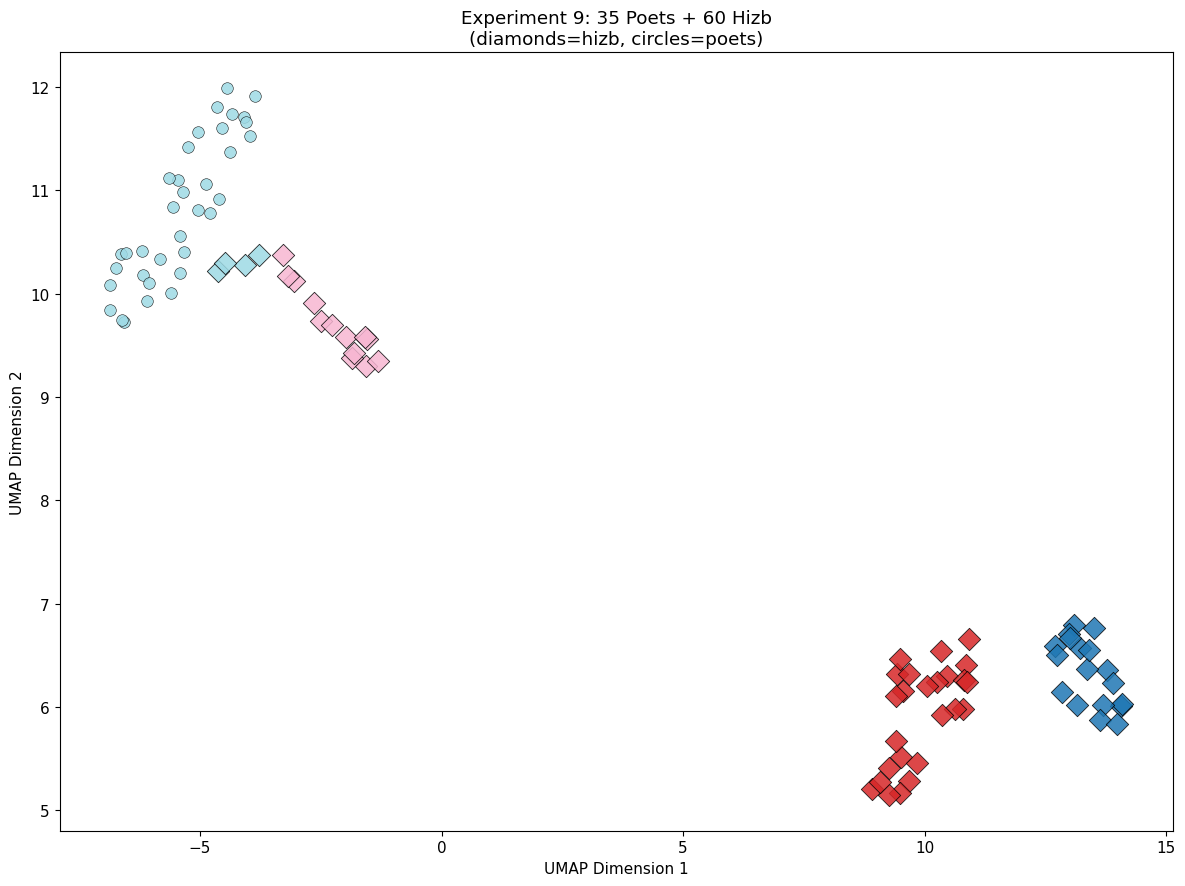

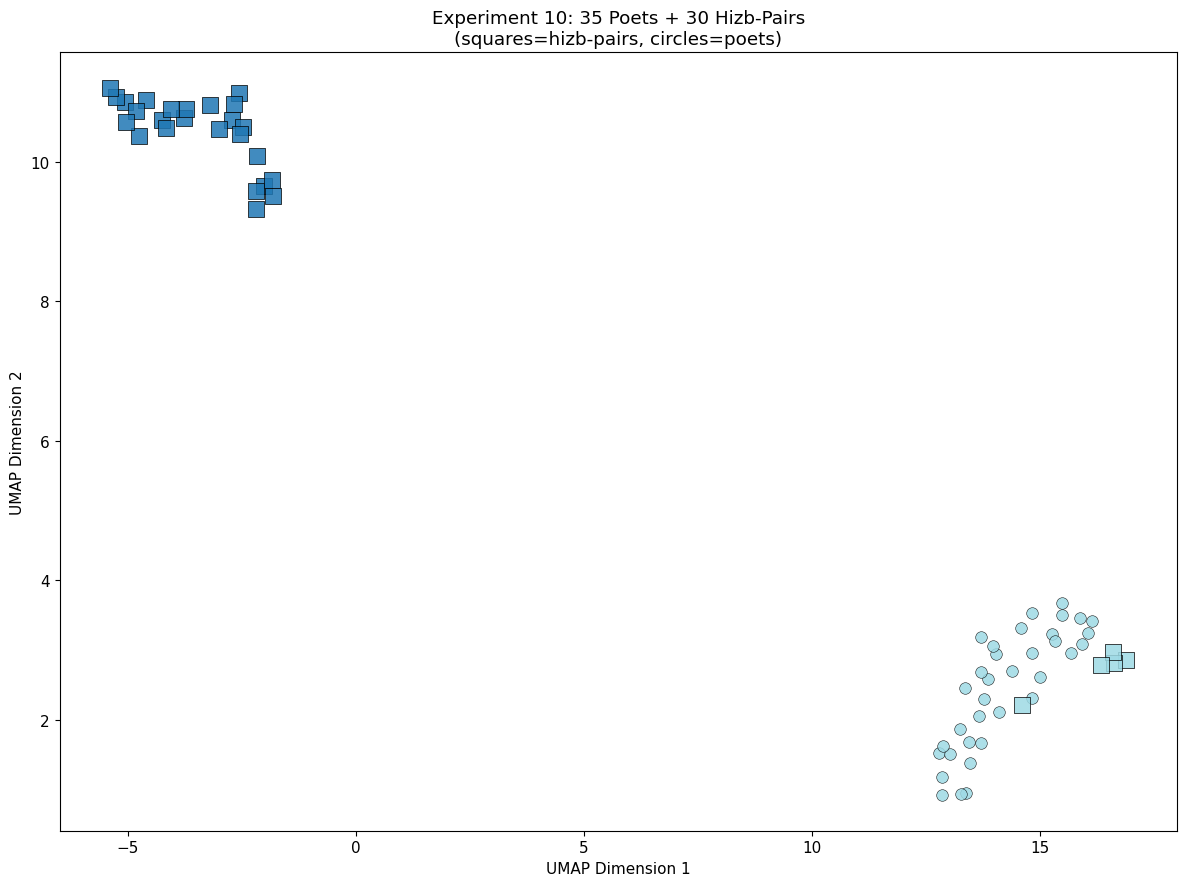

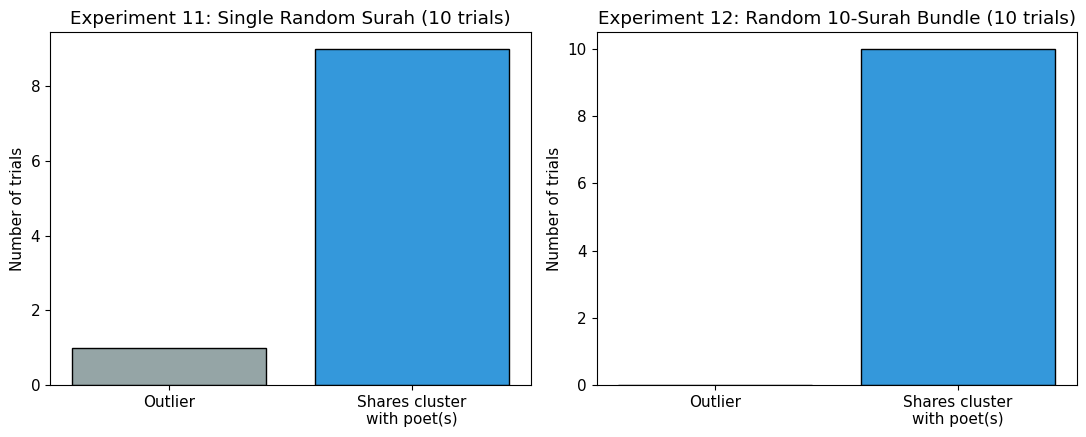

All figures saved.


In [9]:
# CELL 9 -- Figures for Experiments 9-12
def plot_two_type(df, title, save_name, type_b_name, type_b_marker):
    fig, ax = plt.subplots(figsize=(12, 9))
    unique_clusters = sorted(df["cluster"].unique())
    n_clust_plot = len([c for c in unique_clusters if c >= 0])
    colors = plt.cm.tab20(np.linspace(0, 1, max(n_clust_plot, 1)))
    for cl in unique_clusters:
        sub = df[df["cluster"] == cl]
        color = "gray" if cl == -1 else colors[cl % len(colors)]
        poet_sub = sub[sub["type"] == "Poet"]
        b_sub = sub[sub["type"] == type_b_name]
        if len(poet_sub) > 0:
            ax.scatter(poet_sub["umap_x"], poet_sub["umap_y"], c=[color], marker="o", s=70,
                      alpha=0.85, edgecolors="black", linewidth=0.4)
        if len(b_sub) > 0:
            ax.scatter(b_sub["umap_x"], b_sub["umap_y"], c=[color], marker=type_b_marker, s=130,
                      alpha=0.85, edgecolors="black", linewidth=0.6)
    ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()

plot_two_type(exp9_df, f"Experiment 9: {len(well_documented_poet_embeddings)} Poets + 60 Hizb\n(diamonds=hizb, circles=poets)",
             "experiment9_umap.png", "Hizb", "D")
plot_two_type(exp10_df, f"Experiment 10: {len(well_documented_poet_embeddings)} Poets + 30 Hizb-Pairs\n(squares=hizb-pairs, circles=poets)",
             "experiment10_umap.png", "HizbPair", "s")

# Summary bar chart: Exp 11 and Exp 12 outlier rates
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(["Outlier", "Shares cluster\nwith poet(s)"], [n_outlier_11, 10 - n_outlier_11],
           color=["#95a5a6", "#3498db"], edgecolor="black")
axes[0].set_title("Experiment 11: Single Random Surah (10 trials)")
axes[0].set_ylabel("Number of trials")
axes[1].bar(["Outlier", "Shares cluster\nwith poet(s)"], [n_outlier_12, 10 - n_outlier_12],
           color=["#95a5a6", "#3498db"], edgecolor="black")
axes[1].set_title("Experiment 12: Random 10-Surah Bundle (10 trials)")
axes[1].set_ylabel("Number of trials")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "experiment11_12_summary.png", dpi=300, bbox_inches="tight")
plt.show()

print("All figures saved.")

In [10]:
# CELL 10 -- Final report
report_path = REPORTS_DIR / "experiments_9_12_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("EXPERIMENTS 9-12: HIZB GROUPINGS + RANDOM SAMPLING\n")
    f.write("=" * 70 + "\n\n")

    f.write("EXPERIMENT 9: 60 HIZB + 35 POETS\n" + "-" * 40 + "\n")
    for k, v in exp9_metrics.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  Hizb in mixed clusters: {hizb_in_mixed9} / {len(hizb_rows9)} "
            f"({hizb_in_mixed9/len(hizb_rows9)*100:.1f}%)\n")

    f.write("\nEXPERIMENT 10: 30 HIZB-PAIRS + 35 POETS\n" + "-" * 40 + "\n")
    for k, v in exp10_metrics.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  Pairs in mixed clusters: {pairs_in_mixed10} / {len(pair_rows10)} "
            f"({pairs_in_mixed10/len(pair_rows10)*100:.1f}%)\n")

    f.write("\nEXPERIMENT 11: 10x RANDOM SINGLE SURAH\n" + "-" * 40 + "\n")
    f.write(exp11_df.to_string(index=False) + "\n")
    f.write(f"  Outliers: {n_outlier_11}/10\n")

    f.write("\nEXPERIMENT 12: 10x RANDOM 10-SURAH BUNDLE\n" + "-" * 40 + "\n")
    f.write(exp12_df.to_string(index=False) + "\n")
    f.write(f"  Outliers: {n_outlier_12}/10\n")

    f.write("\nHOW TO READ THIS\n" + "-" * 40 + "\n")
    f.write("  Experiments 9-10 test whether finer (hizb) or coarser (hizb-pair)\n")
    f.write("  groupings than whole surahs change the separation pattern seen\n")
    f.write("  in Experiment 8. Experiments 11-12 test how consistent the result\n")
    f.write("  is across different random samples -- if outlier/mixing rates vary\n")
    f.write("  a lot across the 10 trials, that means the result is sensitive to\n")
    f.write("  which specific text is chosen, not a stable overall pattern.\n")

print(f"Report written to {report_path}")
print()
print(open(report_path, encoding="utf-8").read())

Report written to output\reports\experiments_9_12_report.txt

EXPERIMENTS 9-12: HIZB GROUPINGS + RANDOM SAMPLING

EXPERIMENT 9: 60 HIZB + 35 POETS
----------------------------------------
  n_entities: 95
  n_clusters: 4
  n_outliers: 0
  silhouette: 0.7385313510894775
  Hizb in mixed clusters: 4 / 60 (6.7%)

EXPERIMENT 10: 30 HIZB-PAIRS + 35 POETS
----------------------------------------
  n_entities: 65
  n_clusters: 2
  n_outliers: 0
  silhouette: 0.8922486305236816
  Pairs in mixed clusters: 5 / 30 (16.7%)

EXPERIMENT 11: 10x RANDOM SINGLE SURAH
----------------------------------------
 trial  surah_number  surah_name  is_outlier  poets_sharing_cluster  n_clusters_total
     1            81   At-Takwir        True                      0                 4
     2             5   Al-Maaida       False                      9                 3
     3            41    Fussilat       False                      9                 3
     4            70 Al-Ma'aarij       False               

## Done

Output in `output/`:
- `output/tables/experiment9_clusters.csv`, `experiment10_clusters.csv` —
  full cluster assignments
- `output/tables/experiment11_results.csv`, `experiment12_results.csv` —
  all 10 trials each
- `output/figures/` — UMAP plots for Exp 9 and 10, summary chart for
  Exp 11 and 12
- `output/reports/experiments_9_12_report.txt` — everything together

Send this back the same way as before, and I'll build the second report.